In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import joblib
import gradio as gr





#  2️⃣ Load Dataset

In [5]:
# Load dataset
file_path = "Final_dataset.xlsx"   # Change path if needed
df = pd.read_excel(file_path, sheet_name='Worksheet')
df = df[['State', 'Region', 'Soil_Type', 'Temperature (°C)', 'Humidity (%)', 'Rainfall (mm)', 'pH', 'Nitrogen (N)', 'Phosphorus (P)', 'Potassium (K)', 'Organic_Carbon (%)', 'Electrical_Conductivity (dS/m)', 'Crop']]
print("✅ Dataset Loaded Successfully!")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

✅ Dataset Loaded Successfully!
Shape: (50000, 13)
Columns: ['State', 'Region', 'Soil_Type', 'Temperature (°C)', 'Humidity (%)', 'Rainfall (mm)', 'pH', 'Nitrogen (N)', 'Phosphorus (P)', 'Potassium (K)', 'Organic_Carbon (%)', 'Electrical_Conductivity (dS/m)', 'Crop']


# 3️⃣ Initial Data Inspection

In [6]:
print("\nFirst 5 Rows:")
df.head()





First 5 Rows:


,State,Region,Soil_Type,Temperature (°C),Humidity (%),Rainfall (mm),pH,Nitrogen (N),Phosphorus (P),Potassium (K),Organic_Carbon (%),Electrical_Conductivity (dS/m),Crop
0,West Bengal,Central,Black,25.02,87.78,125.39,7.03,208.84,88.46,165.86,0.98,1.75,Sugarcane
1,Maharashtra,South,Red,26.69,35.83,44.09,5.28,91.76,45.77,42.49,1.98,1.63,Millets
2,Rajasthan,Central,Arid,31.40,44.86,44.41,6.45,95.46,41.74,45.02,0.55,1.61,Millets
3,Rajasthan,East,Alluvial,19.17,55.90,95.06,6.35,174.69,53.34,40.33,1.43,1.68,Maize
4,Rajasthan,South,Arid,27.27,57.26,118.51,6.28,102.32,35.53,108.16,1.91,1.98,Cotton


In [7]:
print("\nMissing Values:")
df.isnull().sum()



Missing Values:


,0
State,0
Region,0
Soil_Type,0
Temperature (°C),0
Humidity (%),0
Rainfall (mm),0
pH,0
Nitrogen (N),0
Phosphorus (P),0
Potassium (K),0


In [8]:

print("\nData Types:")
df.dtypes


Data Types:


,0
State,object
Region,object
Soil_Type,object
Temperature (°C),float64
Humidity (%),float64
Rainfall (mm),float64
pH,float64
Nitrogen (N),float64
Phosphorus (P),float64
Potassium (K),float64


In [9]:
print("Dataset size:", df.shape)
print("\nCrop distribution:")
print(df['Crop'].value_counts())


Dataset size: (50000, 13)

Crop distribution:
Crop
Pulses       7213
Cotton       7210
Rice         7189
Sugarcane    7141
Maize        7122
Wheat        7092
Millets      7033
Name: count, dtype: int64


# --- 4️⃣ Encode Categorical Columns ---

In [10]:
# label_encoders = {}
# categorical_cols = ['State', 'Region', 'Soil_Type', 'Crop']

# for col in categorical_cols:
#     le = LabelEncoder()
#     df[col] = le.fit_transform(df[col])
#     label_encoders[col] = le

from sklearn.preprocessing import LabelEncoder

label_encoders = {}
categorical_cols = ['State', 'Region', 'Soil_Type', 'Crop']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

    # Print mapping
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"\n📘 Label Encoding for '{col}':")
    for k, v in mapping.items():
        print(f"   {k}  -->  {v}")



📘 Label Encoding for 'State':
   Gujarat  -->  0
   Karnataka  -->  1
   Maharashtra  -->  2
   Punjab  -->  3
   Rajasthan  -->  4
   Tamil Nadu  -->  5
   Uttar Pradesh  -->  6
   West Bengal  -->  7

📘 Label Encoding for 'Region':
   Central  -->  0
   East  -->  1
   North  -->  2
   South  -->  3
   West  -->  4

📘 Label Encoding for 'Soil_Type':
   Alluvial  -->  0
   Arid  -->  1
   Black  -->  2
   Clay  -->  3
   Laterite  -->  4
   Loamy  -->  5
   Red  -->  6
   Saline  -->  7

📘 Label Encoding for 'Crop':
   Cotton  -->  0
   Maize  -->  1
   Millets  -->  2
   Pulses  -->  3
   Rice  -->  4
   Sugarcane  -->  5
   Wheat  -->  6


# --- 5️⃣ Exploratory Data Analysis (EDA) ---


/tmp/ipython-input-3483003872.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=label_encoders['Crop'].inverse_transform(df['Crop']), palette='viridis')


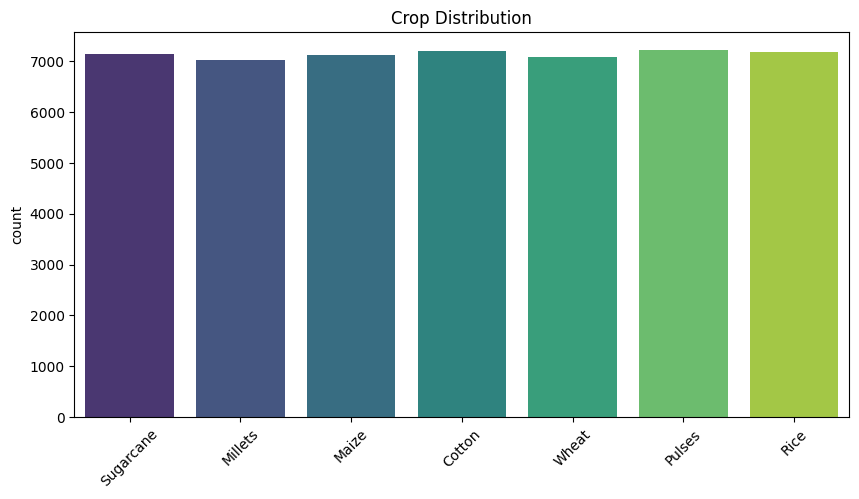

In [11]:
plt.figure(figsize=(10, 5))
sns.countplot(x=label_encoders['Crop'].inverse_transform(df['Crop']), palette='viridis')
plt.title("Crop Distribution")
plt.xticks(rotation=45)
plt.show()

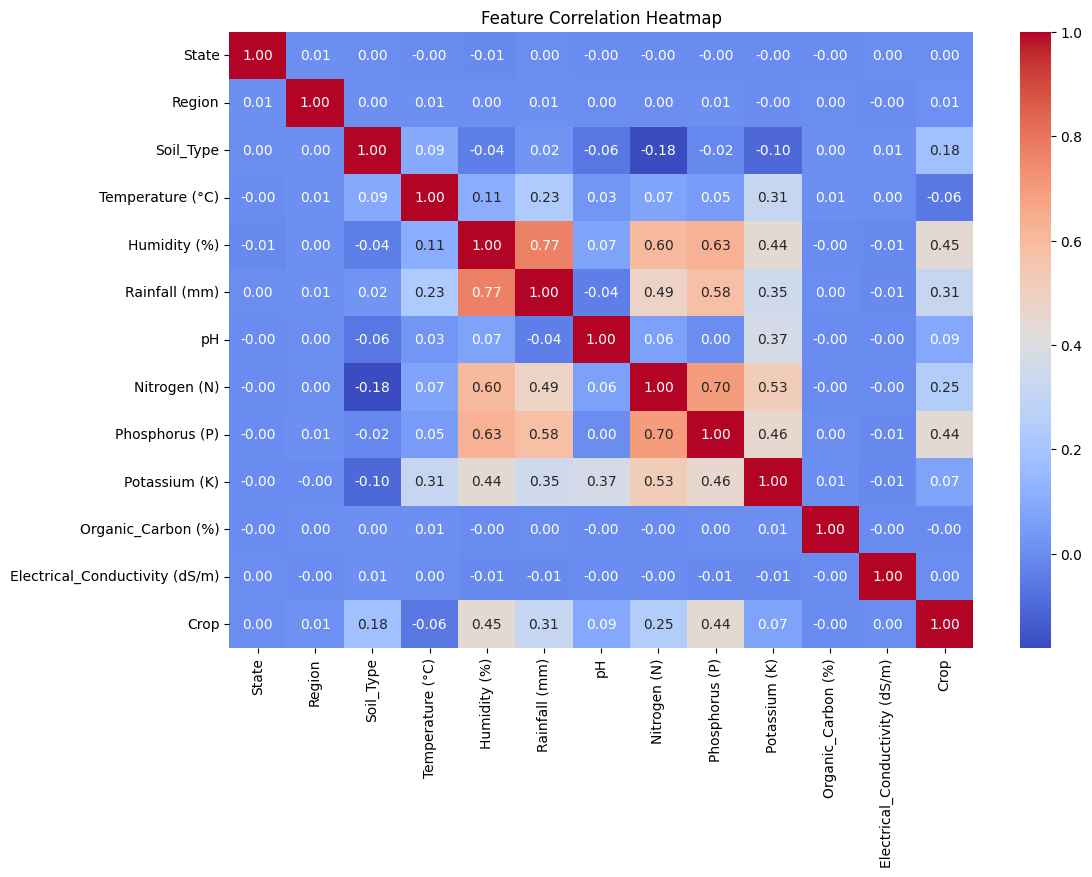

In [12]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

# --- 6️⃣ Split Data ---


In [13]:
X = df.drop('Crop', axis=1)
y = df['Crop']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# --- 7️⃣ Feature Scaling ---


In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 8️⃣ Train Multiple Models ---

In [15]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: Accuracy = {acc:.4f}")

Logistic Regression: Accuracy = 0.9996
Random Forest: Accuracy = 1.0000
Decision Tree: Accuracy = 1.0000
SVM: Accuracy = 0.9998
KNN: Accuracy = 0.9960
Gradient Boosting: Accuracy = 1.0000


# --- 9️⃣ Select Best Model ---

In [16]:

best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print("\n🎯 Best Model:", best_model_name)
print("Accuracy:", results[best_model_name])


🎯 Best Model: Random Forest
Accuracy: 1.0



# --- 🔟 Evaluate Best Model ---

In [17]:

y_pred = best_model.predict(X_test_scaled)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1455
           1       1.00      1.00      1.00      1418
           2       1.00      1.00      1.00      1452
           3       1.00      1.00      1.00      1505
           4       1.00      1.00      1.00      1369
           5       1.00      1.00      1.00      1403
           6       1.00      1.00      1.00      1398

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



# --- 1️⃣1️⃣ Save Artifacts ---

In [18]:

joblib.dump(best_model, "best_crop_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(label_encoders, "label_encoders.pkl")

print("\n💾 Model and preprocessing objects saved successfully!")


💾 Model and preprocessing objects saved successfully!


# 1️⃣2️⃣ Gradio Interface

In [19]:
import pandas as pd
import joblib
import gradio as gr

# Load the trained components
model = joblib.load("best_crop_model.pkl")
scaler = joblib.load("scaler.pkl")
label_encoders = joblib.load("label_encoders.pkl")

# Manual label mappings (from your earlier encoding printout)
state_map = {
    "Gujarat": 0, "Karnataka": 1, "Maharashtra": 2, "Punjab": 3,
    "Rajasthan": 4, "Tamil Nadu": 5, "Uttar Pradesh": 6, "West Bengal": 7
}

region_map = {
    "Central": 0, "East": 1, "North": 2, "South": 3, "West": 4
}

soil_map = {
    "Alluvial": 0, "Arid": 1, "Black": 2, "Laterite": 3,
    "Peaty": 4, "Red": 5, "Saline": 6
}

crop_map_reverse = {
    0: "Cotton", 1: "Maize", 2: "Millets", 3: "Pulses",
    4: "Rice", 5: "Sugarcane", 6: "Wheat"
}

# Prediction function
def predict_crop(State, Region, Soil_Type, Temperature, Humidity, Rainfall, pH,
                 Nitrogen, Phosphorus, Potassium, Organic_Carbon, Electrical_Conductivity):

    # Map human-readable input to encoded values
    input_data = pd.DataFrame({
        'State': [state_map[State]],
        'Region': [region_map[Region]],
        'Soil_Type': [soil_map[Soil_Type]],
        'Temperature (°C)': [Temperature],
        'Humidity (%)': [Humidity],
        'Rainfall (mm)': [Rainfall],
        'pH': [pH],
        'Nitrogen (N)': [Nitrogen],
        'Phosphorus (P)': [Phosphorus],
        'Potassium (K)': [Potassium],
        'Organic_Carbon (%)': [Organic_Carbon],
        'Electrical_Conductivity (dS/m)': [Electrical_Conductivity]
    })

    # Scale numeric features
    input_scaled = scaler.transform(input_data)

    # Predict using the model
    pred = model.predict(input_scaled)[0]
    crop_name = crop_map_reverse[pred]

    return f"🌾 Recommended Crop: {crop_name}"

# Launch Gradio App
iface = gr.Interface(
    fn=predict_crop,
    inputs=[
        gr.Dropdown(label="State", choices=list(state_map.keys())),
        gr.Dropdown(label="Region", choices=list(region_map.keys())),
        gr.Dropdown(label="Soil Type", choices=list(soil_map.keys())),
        gr.Number(label="Temperature (°C)", value=25.0),
        gr.Number(label="Humidity (%)", value=60.0),
        gr.Number(label="Rainfall (mm)", value=150.0),
        gr.Number(label="pH", value=6.5),
        gr.Number(label="Nitrogen (N)", value=100),
        gr.Number(label="Phosphorus (P)", value=50),
        gr.Number(label="Potassium (K)", value=100),
        gr.Number(label="Organic Carbon (%)", value=1.0),
        gr.Number(label="Electrical Conductivity (dS/m)", value=1.0)
    ],
    outputs=gr.Textbox(label="Predicted Crop"),
    title="🌿 Crop Prediction System",
    description="Enter soil, weather, and nutrient parameters to predict the best crop to grow."
)

iface.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c94077de779b29fd25.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


<Figure size 800x600 with 0 Axes>

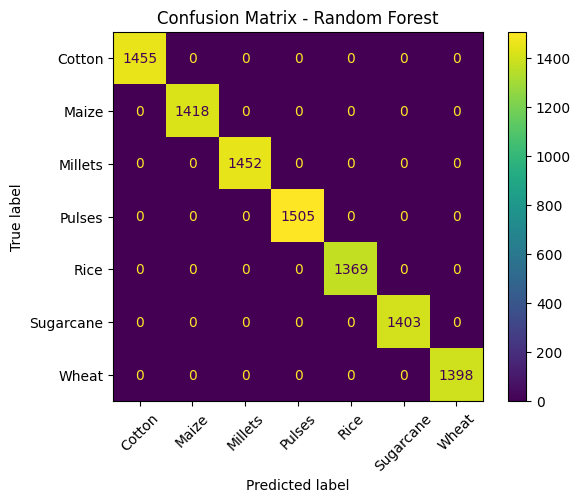

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred = best_model.predict(X_test_scaled)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Get class labels (inverse transform)
class_labels = label_encoders['Crop'].inverse_transform(sorted(y.unique()))

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

plt.figure(figsize=(8, 6))
disp.plot(cmap='viridis', xticks_rotation=45)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()
